In [60]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
import os
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from utils import *

In [62]:
output_dir = '/Users/ahmed/Desktop/msc-24/TND/workflow_parallelization/results_workflow_4_facts_law'

In [72]:
# key case --> 1
# not key case --> 0

def transalte_importance_score(importance_score):
    importance_score = int(importance_score)
    if importance_score == 1:
        return 1
    else:
        return 0

def return_binary_classification(key_case_importance):
    if 'NOT KEY CASE' in key_case_importance:
        return 0
    else:
        if 'KEY CASE' in key_case_importance:
            return 1
        else:
            print("Error: a7aaaaaa")

def get_df(output_dir = './results_facts_openai/', keep_classes = [1,2,3,4]):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        if result == ".DS_Store":
            continue
        result_data = load_json(os.path.join(output_dir, result))
        if int(result_data["ground_truth"]) not in keep_classes:
            continue
        data.append(
            {
                "classification": return_binary_classification(result_data["key_case_importance"]),
                "ground_truth": transalte_importance_score(result_data["ground_truth"]),
            }
        )

    df = pd.DataFrame(data)
    return df

def get_heatmap(df: pd.DataFrame, target_col: str, pred_col: str):
    """Plot and display a heatmap of the confusion matrix."""

    cm = confusion_matrix(df[target_col], df[pred_col], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

def get_metrics_binary(df):

    # Ground truth: 1 for key case, 0 for not key case
    y_true = df['ground_truth']
    # Model predictions: 1 for key case, 0 for not key case
    y_pred = df['classification']

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    # Classification report for additional insights
    rreport = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"], output_dict=True)
    report = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"])

    # Extracting micro and macro F1 scores
    micro_f1 = rreport["accuracy"]  # Micro F1 is equivalent to accuracy in binary classification
    macro_f1 = rreport["macro avg"]["f1-score"]

    # Presenting results
    metrics = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }
    return metrics, report

In [78]:
df = get_df(output_dir, keep_classes=[1,2,3,4])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.4,
 'Precision': 0.29314420803782504,
 'Recall': 0.992,
 'F1 Score': 0.45255474452554745,
 'Micro F1': 0.4,
 'Macro F1': 0.3944189651831277}

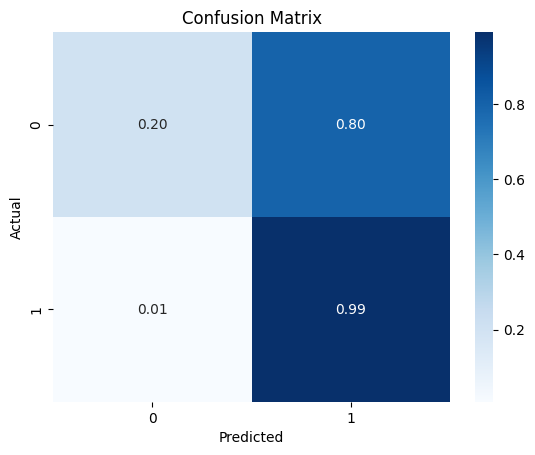

In [79]:
get_heatmap(df, "ground_truth", "classification")

In [74]:
df = get_df(output_dir, keep_classes=[1,2])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.504,
 'Precision': 0.5020242914979757,
 'Recall': 0.992,
 'F1 Score': 0.6666666666666666,
 'Micro F1': 0.504,
 'Macro F1': 0.3489583333333333}

In [75]:
df = get_df(output_dir, keep_classes=[1,3])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.52,
 'Precision': 0.5102880658436214,
 'Recall': 0.992,
 'F1 Score': 0.6739130434782609,
 'Micro F1': 0.52,
 'Macro F1': 0.3824110671936759}

In [80]:
df = get_df(output_dir, keep_classes=[1,4])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.768,
 'Precision': 0.6850828729281768,
 'Recall': 0.992,
 'F1 Score': 0.8104575163398693,
 'Micro F1': 0.768,
 'Macro F1': 0.7557442220874604}

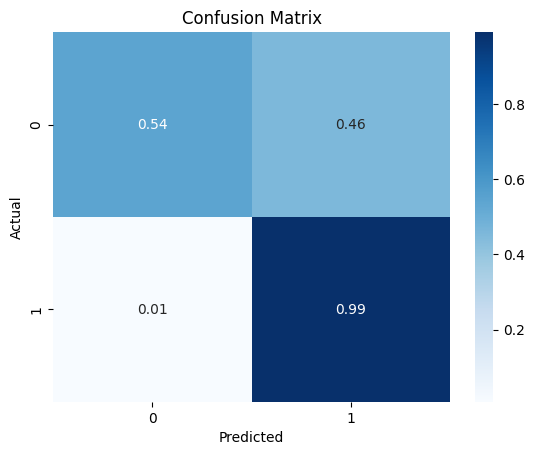

In [81]:
get_heatmap(df, "ground_truth", "classification")

In [66]:
def transalte_importance_score(importance_score):
    importance_score = int(importance_score)
    if importance_score in [1, 2]:  # Key case
        return 1
    elif importance_score == 3:  # Medium importance
        return 2
    elif importance_score == 4:  # Low importance
        return 3
    else:
        raise ValueError("Invalid importance score: expected 1, 2, 3, or 4.")
    
def return_binary_classification(key_case_importance):
    if 'HIGH' in key_case_importance:  # Key case
        return 1
    elif 'MEDIUM' in key_case_importance:  # Medium importance
        return 2
    elif 'LOW' in key_case_importance:  # Low importance
        return 3
    else:
        raise ValueError("Invalid classification: expected 'HIGH', 'MEDIUM', or 'LOW'.")

def get_df(output_dir='./results_facts_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        if result == ".DS_Store":
            continue
        result_data = load_json(os.path.join(output_dir, result))
        data.append(
            {
                "classification": return_binary_classification(result_data["three_levels_importance"]),
                "ground_truth": transalte_importance_score(result_data["ground_truth"]),
            }
        )

    df = pd.DataFrame(data)
    return df

df = get_df(output_dir)

# Ground truth and model predictions
y_true = df['ground_truth']
y_pred = df['classification']

# Calculate metrics for multiclass classification
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_micro = precision_score(y_true, y_pred, average="micro")
recall_micro = recall_score(y_true, y_pred, average="micro")
f1_micro = f1_score(y_true, y_pred, average="micro")

# Classification report for additional insights
report = classification_report(y_true, y_pred, target_names=["Key Case", "Medium Importance", "Low Importance"])

# Extracting metrics
metrics = {
    "Accuracy": accuracy,
    "Precision (Macro)": precision_macro,
    "Recall (Macro)": recall_macro,
    "F1 Score (Macro)": f1_macro,
    "Precision (Micro)": precision_micro,
    "Recall (Micro)": recall_micro,
    "F1 Score (Micro)": f1_micro,
}

metrics


{'Accuracy': 0.51,
 'Precision (Macro)': 0.5871735059824177,
 'Recall (Macro)': 0.3666666666666667,
 'F1 Score (Macro)': 0.30944066781071106,
 'Precision (Micro)': 0.51,
 'Recall (Micro)': 0.51,
 'F1 Score (Micro)': 0.51}

In [67]:
print(report)

                   precision    recall  f1-score   support

         Key Case       0.60      0.94      0.74       250
Medium Importance       0.16      0.14      0.15       125
   Low Importance       1.00      0.02      0.05       125

         accuracy                           0.51       500
        macro avg       0.59      0.37      0.31       500
     weighted avg       0.59      0.51      0.42       500



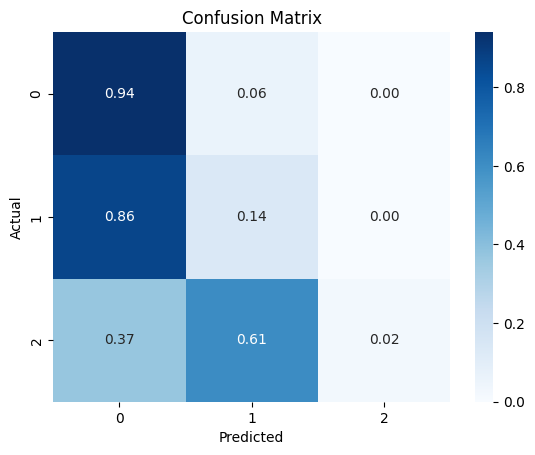

In [68]:
get_heatmap(df, 'ground_truth',  'classification')  

In [69]:
def transalte_importance_score(importance_score):
    return int(importance_score)

    
def return_binary_classification(key_case_importance):
    if 'LEVEL 1' in key_case_importance:  # Key case
        return 1
    elif 'LEVEL 2' in key_case_importance:  # HIGH importance
        return 2
    elif 'LEVEL 3' in key_case_importance:  # Medium importance
        return 3
    elif 'LEVEL 4' in key_case_importance:  # Low importance
        return 4
    else:
        print(key_case_importance)
        raise ValueError("Invalid classification: expected 'HIGH', 'MEDIUM', or 'LOW'.")

def get_df(output_dir='./results_facts_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        if result == ".DS_Store":
            continue
        result_data = load_json(os.path.join(output_dir, result))
        data.append(
            {
                "classification": return_binary_classification(result_data["four_levels_importance"]),
                "ground_truth": transalte_importance_score(result_data["ground_truth"]),
            }
        )

    df = pd.DataFrame(data)
    return df

df = get_df(output_dir)

# Ground truth and model predictions
y_true = df['ground_truth']
y_pred = df['classification']

# Calculate metrics for multiclass classification
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

precision_micro = precision_score(y_true, y_pred, average="micro")
recall_micro = recall_score(y_true, y_pred, average="micro")
f1_micro = f1_score(y_true, y_pred, average="micro")

# Classification report for additional insights
report = classification_report(y_true, y_pred, target_names=["Key Case","HIGH Importance", "Medium Importance", "Low Importance"])

# Extracting metrics
metrics = {
    "Accuracy": accuracy,
    "Precision (Macro)": precision_macro,
    "Recall (Macro)": recall_macro,
    "F1 Score (Macro)": f1_macro,
    "Precision (Micro)": precision_micro,
    "Recall (Micro)": recall_micro,
    "F1 Score (Micro)": f1_micro,
}

metrics


/Users/ahmed/thesis24/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ahmed/thesis24/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ahmed/thesis24/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ahmed/the

{'Accuracy': 0.26,
 'Precision (Macro)': 0.2273298997967907,
 'Recall (Macro)': 0.26,
 'F1 Score (Macro)': 0.18858023567025023,
 'Precision (Micro)': 0.26,
 'Recall (Micro)': 0.26,
 'F1 Score (Micro)': 0.26}

In [70]:
print(report)

                   precision    recall  f1-score   support

         Key Case       0.26      0.59      0.36       125
  HIGH Importance       0.25      0.40      0.31       125
Medium Importance       0.40      0.05      0.09       125
   Low Importance       0.00      0.00      0.00       125

         accuracy                           0.26       500
        macro avg       0.23      0.26      0.19       500
     weighted avg       0.23      0.26      0.19       500



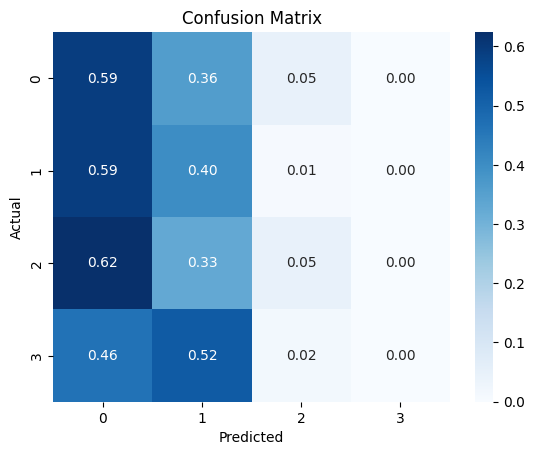

In [71]:
get_heatmap(df, 'ground_truth',  'classification')  